In [ ]:
import pandas as pd
from data_cleaning import Ausreißer

relevant_data_uncleaned = pd.read_csv('data/relevant_data_uncleaned.csv')
relevant_data_without_outlires = Ausreißer(relevant_data_uncleaned,
                                           default_outlier_strategy = "delete",
                                           except_replace_0=[],
                                           except_replace_mean=[],
                                           except_delete=[],
                                           ignore=[])



#postTransactionAmounts.sharesOwnedFollowingTransaction Korrelation mit amounts.Share
#reportingOwner.relationship.isTenPercentOwner: Varianz = 0.091504, Korrelation mit t_1_percent_change_since_4d = 0.039
#reportingOwner.relationship.isOther: Varianz = 0.061755, Korrelation mit t_1_percent_change_since_4d = 0.041
#USRECD: Varianz = 0.000000
relevant_data_without_outlires_corr_var = relevant_data_without_outlires.drop(columns=['postTransactionAmounts.sharesOwnedFollowingTransaction',
                                                                          'reportingOwner.relationship.isTenPercentOwner',
                                                                          'reportingOwner.relationship.isOther', 
                                                                          'USRECD'])

#percent
# calculate percentage since day 0
ref = all_df_of_close_data[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = (abs_mat - ref) / ref
percent_df = pd.DataFrame(percent_mat)


In [7]:
relevant_data_without_outlires_corr_var

,amounts.shares,direct_ownership,amounts.pricePerShare,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,t_1_percent_change_since_4d,t_10_percent_change_since_198d,transaction_month,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,holding_change_percent,high_change_in_holdings
5795,2000.0,0,2.25,True,False,1,1,7,14,0,3.0,0,-0.682300,1
5796,100.0,0,2.20,True,False,1,1,7,14,0,3.0,0,-0.033884,1
5799,1000.0,1,5.05,False,False,1,1,7,104,1,4.0,0,-0.206740,1
5800,2000.0,1,5.00,False,False,1,1,7,104,1,4.0,0,-0.412626,1
5801,1000.0,1,4.95,False,False,1,1,7,104,1,4.0,0,-0.205465,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,100.0,1,23.81,True,False,1,0,7,22,0,6.0,1,-4.262575,0
141052,100.0,1,4.08,True,True,0,0,7,43,1,2.0,0,-0.150218,1
141053,164.0,1,19.64,True,False,1,0,7,21,0,1.0,1,-3.586267,0
141054,306.0,1,10.30,True,False,1,1,7,18,0,1.0,1,-1.845597,0


In [12]:
from scipy.stats import boxcox, skew, zscore
from data_cleaning import stats
def Skalierung(df, scale_stratagy = "alle", variable=None):
    """
    Wendet den Z-Score auf die Liste der übergebenen Variablen an. Per Default werden alle Variablen skaliert, 
    die keine bool Variablen sind.
    Empfohlen bei Logistic Regression aber nicht bei Decision Trees, Random Forest, XGBoost. Betsenfalls vorher
    Transformieren und dann Z-Score anwenden.
    
    Input:
        df (pd.DataFrame): Ursprüngliches DataFrame
        scale_stratagy (string): "alle" oder "ausgewählte"
        variable (list): Name der Spalte im DataFrame, z.B. ["Variable_1"]
        
    Output:
        pd.DataFrame: DataFrame mit ggf. skalierten Variablen
        Print Statement: Information über skalierte Variablen
        pd.DataFrame durch stats(df): Übersicht mit deskreptiven Statistiken und Missings zu jeder Variable
        csv durch stats(df): Übersicht mit deskreptiven Statistiken und Missings zu jeder Variable im Ordner Data/Exporte abgespeichert
    """
    
    if scale_stratagy=="alle":
        columns = df.select_dtypes(include=['number']).columns
    elif scale_stratagy=="ausgewählte":
    
        for var in scale_stratagy:
            df[var] = zscore(df[var])
            print(f"{var} wurde mit dem zscore angepasst")

    stats(df)


    return df

final = Skalierung(relevant_data_without_outlires_corr_var,
                   scale_stratagy = ['amounts.shares', 'amounts.pricePerShare',
                                    'filing_count_reportingOwner.name',
                                    'trades_14d', 'holding_change_percent'],
                   variable=None)


,dtype,na_count,count,unique,top,freq,mean,std,min,25%,50%,75%,max,skew,var
amounts.shares,float64,0,60187.0,NaN,NaN,NaN,1949.801302,2678.880349,0.002,200.0,848.0,2500.0,12184.0,1.882395,7176399.923444
direct_ownership,int64,0,60187.0,NaN,NaN,NaN,0.771894,0.419615,0.0,1.0,1.0,1.0,1.0,-1.295967,0.176076
amounts.pricePerShare,float64,0,60187.0,NaN,NaN,NaN,12.930755,7.500656,2.0,6.5,12.1,18.0426,34.52,0.506850,56.259843
reportingOwner.relationship.isDirector,bool,0,60187,2,True,41470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reportingOwner.relationship.isOfficer,bool,0,60187,2,False,35714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
t_1_percent_change_since_4d,int64,0,60187.0,NaN,NaN,NaN,0.408975,0.491649,0.0,0.0,0.0,1.0,1.0,0.370295,0.241719
t_10_percent_change_since_198d,int64,0,60187.0,NaN,NaN,NaN,0.391829,0.488163,0.0,0.0,0.0,1.0,1.0,0.443191,0.238303
transaction_month,int64,0,60187.0,NaN,NaN,NaN,6.854803,3.334212,1.0,4.0,7.0,10.0,12.0,-0.063332,11.116973
filing_count_reportingOwner.name,int64,0,60187.0,NaN,NaN,NaN,37.198697,42.129763,1.0,7.0,20.0,52.0,205.0,1.689398,1774.916970
high_frequency_trader,int64,0,60187.0,NaN,NaN,NaN,0.339691,0.473608,0.0,0.0,0.0,1.0,1.0,0.676990,0.224305


                Modell  Accuracy   ROC AUC  Precision    Recall
0        Random Forest  0.626926  0.674236   0.689154  0.163165
1  Logistic Regression  0.591028  0.565936   0.507130  0.069910


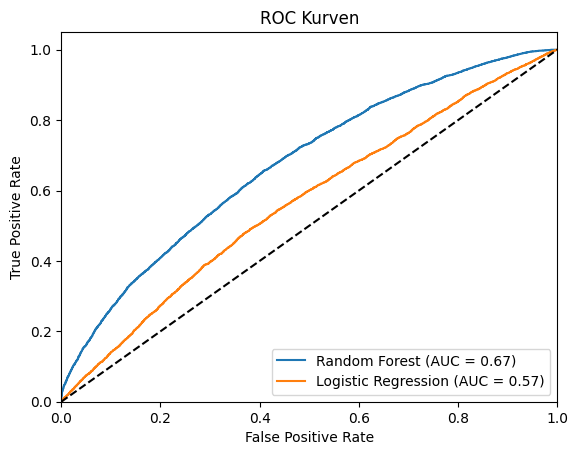

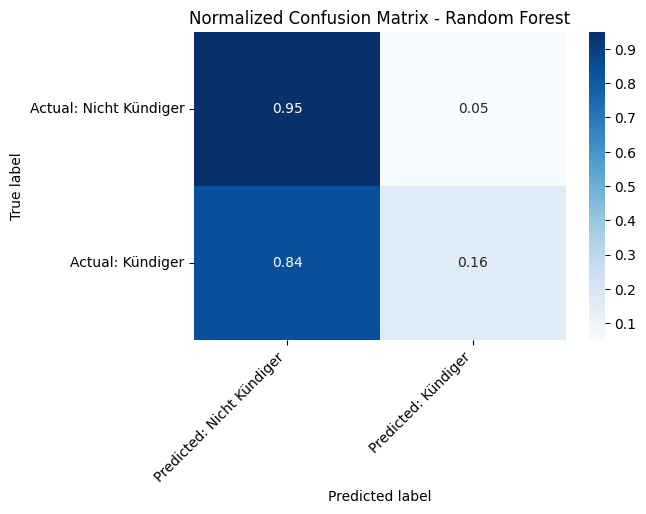

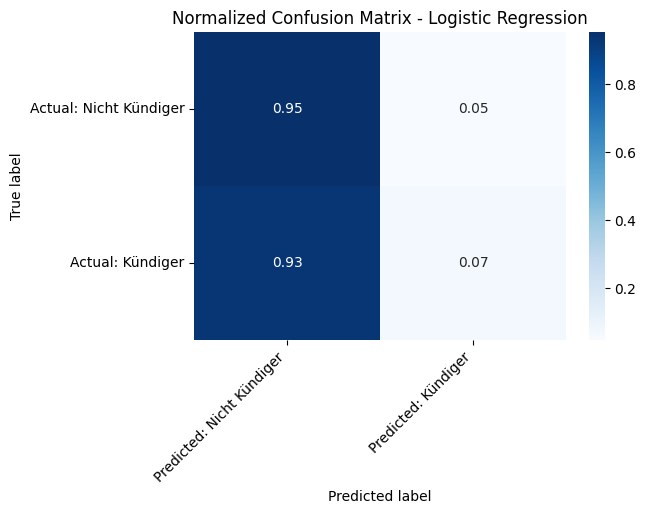

Feature Importance für jedes Modell:
                                        Logistic Regression  Random Forest
high_frequency_trader                              0.096102       0.012144
direct_ownership                                   0.089057       0.023859
high_price                                         0.038060       0.017853
reportingOwner.relationship.isOfficer              0.020877       0.023287
amounts.pricePerShare                              0.019426       0.230966
reportingOwner.relationship.isDirector             0.014098       0.019996
trades_14d                                         0.011246       0.110807
high_change_in_holdings                            0.009852       0.012122
holding_change_percent                             0.002997       0.134524
filing_count_reportingOwner.name                   0.000976       0.142232
transaction_month                                  0.000316       0.094962
amounts.shares                                     0.000045    

In [13]:
# Basics
import numpy as np
import pandas as pd

# Plots
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import plot_tree

# Optional (steht schon im Code, wird aber nicht zwingend verwendet)
from sklearn.utils import resample

df = final

df = df.drop(columns='t_10_percent_change_since_198d')
## Model training, Logistic Regression und Random Forrest, ROC/AUC, Precision/Recall, feature importance, confusion matrix
# Zielvariable
y = df['t_1_percent_change_since_4d']


# Unabhängige Variablen
x_columns = [col for col in df.columns if col != "t_1_percent_change_since_4d"]

# Daten für unabhängige Variablen
X = df[x_columns]

# Aufteilen in Trainings- und Testdaten, 33 % der Daten für Testset und 67 % für Trainingsset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


# Class-Imbalance berücksichtigen (0/1-Labels vorausgesetzt)
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1200,
                                            max_depth=10,
                                            max_features="sqrt",
                                            min_samples_split=20,
                                            min_samples_leaf=10,
                                            class_weight=None,
                                            bootstrap=True,
                                            oob_score=True,
                                            n_jobs=-1,
                                            random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=10000),
}

# Dictionary zum Speichern der Ergebnisse
results = []

# Schleife zum Trainieren und Testen der Modelle
for model_name, model in models.items():
    # Modell trainieren
    model.fit(X_train, y_train)
    
    # Vorhersagen auf Testdaten
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für positive Klasse
    
    # Berechnung der Metriken
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # ROC-Kurve berechnen
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    
    # Ergebnis speichern
    results.append({
        "Modell": model_name,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    
    # ROC-Kurve plotten
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Tabelle der Ergebnisse anzeigen
results_df = pd.DataFrame(results)
print(results_df)

# ROC-Kurve visualisieren
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven')
plt.legend(loc="lower right")
plt.show()

# Loop über alle Modelle
for model_name, model in models.items():
    # Modell trainieren
    model.fit(X_train, y_train)
    
    # Vorhersagen treffen
    y_pred = model.predict(X_test)
    
    # Confusion Matrix berechnen
    cm = confusion_matrix(y_test, y_pred)
    
    # Confusion Matrix in DataFrame umwandeln für besseres Plotting
    df_cm = pd.DataFrame(cm, index=['Actual: Nicht Kündiger', 'Actual: Kündiger'], 
                         columns=['Predicted: Nicht Kündiger', 'Predicted: Kündiger'])
    
    # Konvertiere die Confusion-Matrix-Werte in ein numpy-Array, bevor die Normalisierung durchgeführt wird
    cm_values = df_cm.values.astype('float')  # Numpy-Array erstellen
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]  # Normalisieren
    
    # Normalisierte Confusion-Matrix zurück in DataFrame umwandeln
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)
    
    # Heatmap plotten
    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    
    # Achsentitel und Rotationen anpassen
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    
    # Titel und Achsenbeschriftungen hinzufügen
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    
    # Plot anzeigen
    plt.show()
    
# Dictionary für die Speicherung der Feature-Importances
feature_importances = pd.DataFrame()

# Für Logistic Regression werden die Koeffizienten verwendet
if "Logistic Regression" in models:
    log_reg = models["Logistic Regression"] # Hier wird das Logistic-Regression-Modell aus dem models Dictionary extrahiert und der Variablen log_reg zugewiesen. models könnte eine Sammlung von trainierbaren Modellen sein.
    log_reg.fit(X_train, y_train) # Diese Zeile trainiert (fit) das log_reg Modell mit den Trainingsdaten X_train (Features) und y_train (Zielvariable).
    feature_importances["Logistic Regression"] = np.abs(log_reg.coef_[0]) 

# Für Random Forest verwenden wir die Feature Importances
if "Random Forest" in models:
    rf = models["Random Forest"]
    rf.fit(X_train, y_train)
    feature_importances["Random Forest"] = rf.feature_importances_


# Feature-Namen als Index verwenden
feature_importances.index = X_train.columns

# Tabelle der Feature-Wichtigkeiten sortieren und anzeigen
feature_importances = feature_importances.sort_values(by="Logistic Regression", ascending=False)
print("Feature Importance für jedes Modell:")
print(feature_importances)


In [ ]:

## Odds Ratio & % Wahrscheinlicher Kündiger/nicht-Kündiger Tabelle

# Odds-Ratio-Tabelle mit Richtung und %-Effekt
log_reg = models["Logistic Regression"].fit(X_train, y_train)
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
or_ = np.exp(coefs)

or_table = pd.DataFrame({
    "Koeffizient": coefs,
    "Odds Ratio": or_,
})

# Prozent-Effekt auf die Odds (nicht direkt Wahrscheinlichkeit!)
or_table["% Wahrscheinlicher Kündiger/nicht-Kündiger"] = np.where(
    or_table["Odds Ratio"]>=1,
    (or_table["Odds Ratio"]-1)*100,
    -(1-or_table["Odds Ratio"])*100
).round(1)

or_table = or_table.reindex(or_table["Koeffizient"].abs().sort_values(ascending=False).index)
or_table



## Random Forrest Tree plotten
# Zielvariable
y = df['TF_Kündiger']


# Unabhängige Variablen
x_columns = [col for col in df.columns if col != "TF_Kündiger"]

# Daten für unabhängige Variablen
X = df[x_columns]

# Aufteilen in Trainings- und Testdaten, 33 % der Daten für Testset und 67 % für Trainingsset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


# Class-Imbalance berücksichtigen (0/1-Labels vorausgesetzt)
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

models = {
    "Random Forest": RandomForestClassifier(n_estimators=1200,
                                            max_depth=10,
                                            max_features="sqrt",
                                            min_samples_split=20,
                                            min_samples_leaf=10,
                                            class_weight=None,
                                            bootstrap=True,
                                            oob_score=True,
                                            n_jobs=-1,
                                            random_state=42),
}

# Dictionary zum Speichern der Ergebnisse
results = []

# Schleife zum Trainieren und Testen der Modelle
for model_name, model in models.items():
    # Modell trainieren
    model.fit(X_train, y_train)
    
    # Vorhersagen auf Testdaten
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für positive Klasse

fig, ax = plt.subplots(figsize=(10,10),dpi=300,)
fn = list(X_train.columns) # feature names
cn = [str(cls) for cls in np.unique(y_train)] #classnames

estimator = model.estimators_[0]

plot_tree(estimator,
feature_names=fn,
class_names=cn,
filled=True,
fontsize=3,
ax=ax)

fig.savefig("baum_plot.png", dpi=300, bbox_inches='tight')

plt.show()

